## SETUP: Installations, Imports, Etc.

In [1]:
# conda create --name mike
# conda activate mike
# conda config --append channels conda-forge
# conda install -n mike Pillow

# conda install -n mike numpy
# conda install -n mike scikit-fuzzy
# conda install -n mike matplotlib
# conda install -n mike pandas
# conda install colour-science

from PIL import Image
import math
import numpy as np
import skfuzzy as fuzz
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
import heapq
import copy

# DICHROMAT SIMULATION

In [2]:
# find dichromat simulation of the color (using translated JavaScript code from https://github.com/skratchdot/color-blind)
# takes in rgb code as a three element tuple, returns rgb code of the color a dichromat sees (as a three element tuple)

class blinder:
    def __init__(self, x, y, m, y1):
        self.x = x
        self.y = y
        self.m = m
        self.yi = y1

# protan: {
# 		x: 0.7465,
# 		y: 0.2535,
# 		m: 1.273463,
# 		yi: -0.073894
# 	}
protan = blinder(0.7465, 0.2535, 1.273463, -0.073894)
# deutan: {
# 		x: 1.4,
# 		y: -0.4,
# 		m: 0.968437,
# 		yi: 0.003331
# 	}
deutan = blinder(1.4, -0.4, 0.968437, 0.003331)

def convertRgbToXyz(rgb):
     M =  [0.41242371206635076, 0.21265606784927693, 0.019331987577444885,
	       0.3575793401363035, 0.715157818248362, 0.11919267420354762,
	       0.1804662232369621, 0.0721864539171564, 0.9504491124870351]
     
     R = rgb[0] / 255
     G = rgb[1] / 255
     B = rgb[2] / 255
     # if colorProfile is sRGB
     R = math.pow(((R + 0.055) / 1.055), 2.4) if R > 0.04045 else R / 12.92
     G = math.pow(((G + 0.055) / 1.055), 2.4) if G > 0.04045 else G / 12.92
     B = math.pow(((B + 0.055) / 1.055), 2.4) if B > 0.04045 else B / 12.92
     # gamma correction
     #  R = math.pow(R, 2.2)
	 #  G = math.pow(G, 2.2)
	 #  B = math.pow(B, 2.2)
     X = R * M[0] + G * M[3] + B * M[6]
     Y = R * M[1] + G * M[4] + B * M[7]
     Z = R * M[2] + G * M[5] + B * M[8]
     xyz = (X, Y, Z)
     return xyz

def convertXyzToXyy(o):
    n = o[0] + o[1] + o[2]
    if n == 0:
        # X y Y
        return (0, 0, o[1])
    # X y Y
    return (o[0] / n, o[1] / n, o[1])

def dichromat_simul(rgb, blinder_param, anomalize=False): # toggle anomalize to get protanomaly instead of protanopia or deuteranomaly instead of deuteranopia
# exports.Blind = function (rgb, type, anomalize) {
	# z, v, n,
	#line, c, slope,
	# yi, dx, dy,
	#dX, dY, dZ,
	#dR, dG, dB,
	#_r, _g, _b,
	#ngx, ngz, M,
	#adjust
	
	# if (type === "achroma") { // D65 in sRGB
	# 	z = rgb.R * 0.212656 + rgb.G * 0.715158 + rgb.B * 0.072186;
	# 	z = {R: z, G: z, B: z};
	# 	if (anomalize) {
	# 		v = 1.75;
	# 		n = v + 1;
	# 		z.R = (v * z.R + rgb.R) / n;
	# 		z.G = (v * z.G + rgb.G) / n;
	# 		z.B = (v * z.B + rgb.B) / n;
	# 	}
	# 	return z;
	# }
	
    line = blinder_param # protan or deutan
    
    # c = Xyy
    Xyy = convertXyzToXyy(convertRgbToXyz(rgb))

	# The confusion line is between the source color and the confusion point
    slope = (Xyy[1] - line.y) / (Xyy[0] - line.x)
    yi = Xyy[1] - Xyy[0] * slope; # slope, and y-intercept (at x=0)
    # Find the change in the x and y dimensions (no Y change)
    dx = (line.yi - yi) / (slope - line.m)
    dy = (slope * dx) + yi
    dY = 0
	# Find the simulated colors XYZ coords
    colorX = dx * Xyy[1] / dy
    colorY = Xyy[1]
    colorZ = (1 - (dx + dy)) * Xyy[1] / dy
    z = (colorX, colorY, colorZ) 

    
	# Calculate difference between sim color and neutral color
    ngx = 0.312713 * Xyy[1] / 0.329016 # find neutral grey using D65 white-point
    ngz = 0.358271 * Xyy[1] / 0.329016
    dX = ngx - z[0]
    dZ = ngz - z[2]
	# find out how much to shift sim color toward neutral to fit in RGB space
    M = [
	3.240712470389558, -0.969259258688888, 0.05563600315398933,
	-1.5372626602963142, 1.875996969313966, -0.2039948802843549,
	-0.49857440415943116, 0.041556132211625726, 1.0570636917433989]

    dR = dX * M[0] + dY * M[3] + dZ * M[6] # convert d to linear RGB
    dG = dX * M[1] + dY * M[4] + dZ * M[7]
    dB = dX * M[2] + dY * M[5] + dZ * M[8]

    if dR == 0:
        dR = 0.00000000000000000000000001
    if dG == 0:
        dG = 0.00000000000000000000000001
    if dB == 0:
        dB = 0.00000000000000000000000001    

    R = z[0] * M[0] + z[1] * M[3] + z[2] * M[6] # convert z to linear RGB
    G = z[0] * M[1] + z[1] * M[4] + z[2] * M[7]
    B = z[0] * M[2] + z[1] * M[5] + z[2] * M[8]

    _r = ((0 if R < 0 else 1) - R) / dR
    _g = ((0 if G < 0 else 1) - G) / dG
    _b = ((0 if B < 0 else 1) - B) / dB
    _r = 0 if (_r > 1 or _r < 0) else _r
    _g = 0 if (_g > 1 or _g < 0) else _g
    _b = 0 if (_b > 1 or _b < 0) else _b

    adjust = _r if _r > _g else _g
    if (_b > adjust):
        adjust = _b
          
	# shift proportionally...
    R += adjust * dR
    G += adjust * dG
    B += adjust * dB
	# apply gamma and clamp simulated color...
    gammaCorrection = 2.2
    R = 255 * (
    0 if R <= 0 else 
    (1 if R >= 1 else 
    math.pow(R, 1 / gammaCorrection)))

    B = 255 * (
    0 if B <= 0 else 
    (1 if B >= 1 else 
    math.pow(B, 1 / gammaCorrection)))

    G = 255 * (
    0 if G <= 0 else 
    (1 if G >= 1 else 
    math.pow(G, 1 / gammaCorrection)))
	
    if (anomalize):
        v = 1.75
        n = v + 1
        R = (v * R + rgb[0]) / n
        G = (v * G + rgb[1]) / n
        B = (v * B + rgb[2]) / n
	
    rgb = (R, G, B)
    return rgb

# KEY COLOR EXTRACTION
## Note: All operations completed in RGB color space

In [3]:
# Module 1: Key Color Extraction (all operations completed in RGB color space)

# break image up into grouped color bins
# find representative colors (mean of all colors) of each bin
# find pixel count of each bin
# takes in image path as a string and cube_slength, returns list of representative colors and mapping from each representative color to the pixel count of the bin it represents
# cube_slength recommended interval: [5, 10]
def rep_colors(img_path, cube_slength):

    # set up color bins
    num_chan_bins = math.ceil(255 / cube_slength)
    # maps from lower bound (3-element tuple) of cube
    # to a list of colors 
    bins_to_colors = dict()

    try:
        # open image within RGB color space
        with Image.open(img_path) as img:
            img = img.convert('RGB')
            width, height = img.size

            # for each pixel
            for y in range(height):
                for x in range(width):
                    rgb_val = img.getpixel((x, y))
                    low_r_bound = int(rgb_val[0] / num_chan_bins)
                    low_g_bound = int(rgb_val[1] / num_chan_bins)
                    low_b_bound = int(rgb_val[2] / num_chan_bins)
                    if (low_r_bound, low_g_bound, low_b_bound) in bins_to_colors:
                        bins_to_colors[(low_r_bound, low_g_bound, low_b_bound)].append(rgb_val)
                    else:
                        bins_to_colors[(low_r_bound, low_g_bound, low_b_bound)] = [rgb_val]

            rep_colors = []
            rep_c_to_px_count = dict()

            # iterate through bins, find rep color of each one
            # and populate representative-color-to-pixel-count dictionary
            for bin in bins_to_colors:
                color_list = bins_to_colors[bin]
                avg_red = 0
                avg_green = 0
                avg_blue = 0
                for c in color_list:
                    avg_red += c[0] / len(color_list)
                    avg_green += c[1] / len(color_list)
                    avg_blue += c[2] / len(color_list)
                # avg_red = int(avg_red)
                # avg_green = int(avg_green)
                # avg_blue = int(avg_blue)
                if avg_red > 255:
                    avg_red = 255
                if avg_green > 255:
                    avg_green = 255
                if avg_blue > 255:
                    avg_blue = 255
                rep_colors.append((avg_red, avg_green, avg_blue))
                rep_c_to_px_count[(avg_red, avg_green, avg_blue)] = len(color_list)

            return rep_colors, rep_c_to_px_count

    except FileNotFoundError:
        print("Image file not found at " + img_path)
    except Exception as e:
        print(f"An error occurred: {e}")

In [4]:
# find distance between representative color and dichromat simulation - if the distance is greater than some delta (20-30), they are confusing
# separate colors of the image into 2 sets: Ca (confusing) and Cb (non confusing)
# takes in two lists (representative colors and dichromat colors), where corresponding ones are at the same respective indices
# also takes in a float delta, which represents the maximum distance where two colors may be confused
# returns set of confusing colors and set of non-confusing colors
# delta recommended interval: [20, 30]
def sep_confusing(rep_color_list, dichromat_color_list, delta):
    # sets
    confusing_colors = set()
    non_confusing_colors = set()
    # loop over colors
    for rep_color, dichromat_color in zip(rep_color_list, dichromat_color_list):
        # get distance
        distance = 0
        for i in range(3):
            # squared difference of each RGB channel
            distance += (rep_color[i] - dichromat_color[i]) ** 2
        
        if math.sqrt(distance) < delta:
            non_confusing_colors.add(rep_color)
        else:
            confusing_colors.add(rep_color)
    
    return confusing_colors, non_confusing_colors

In [33]:
# run fuzzy clustering on both sets to get key colors
# takes in a set of colors and number of clusters n
# returns set of n key colors from the given set, and dictionary mapping from cluster centers to cluster members
def fuzzy_clustering(color_set, n):
    # fuzzy expects (features, samples) so transpose the set of colors
    color_list = list(color_set)
    data = np.array(color_list).T
    # print(data)
    m = 1.7
    error = 1e-5
    maxiter = 2000
    # print(data.shape)
    centers, partitioned_matrix, _, _, _, _, _ = fuzz.cluster.cmeans(
        data, c=n, m=m, error=error, maxiter=maxiter, init=None
    )
    centers.tolist()
    # print("CENTERS")
    # print(centers)

    # return cluster centers
    cluster_set = set()
    for c in centers:
        cluster_set.add((float(c[0]), float(c[1]), float(c[2])))

    # map from cluster centers to cluster members
    centers_to_members = dict()
    cluster_assignments = np.argmax(partitioned_matrix, axis=0)
    # print(cluster_assignments)
    # for c in centers:
    #     centers_to_members[tuple(c.tolist())] = []
    for i in range(len(color_list)):
        if tuple(centers[cluster_assignments[i]].tolist()) in centers_to_members:
            centers_to_members[tuple(centers[cluster_assignments[i]].tolist())].append(color_list[i])
        else:
            centers_to_members[tuple(centers[cluster_assignments[i]].tolist())] = [color_list[i]]
        # print(color_list[i])
    # for i in range(len(centers)):
    #     print(partitioned_matrix)
    #     centers_to_members[tuple(centers[i].tolist())] = [tuple(x) for x in partitioned_matrix[i]]

    # print("PARTITIONED MATRIX")
    # print(partitioned_matrix)
    # print("SIZE")
    # print(partitioned_matrix.size)
    # print(centers_to_members)
    return cluster_set, centers_to_members

In [24]:
# takes in dictionary mapping from representative colors to bin pixel counts
# and dictionary mapping from cluster centers to cluster members
# returns dictionary mapping from cluster centers to cardinalities
def compute_cluster_cardinalities(rep_c_to_px_count, centers_to_members):
    center_cardinalities = dict()
    for center in centers_to_members:
        # sum bin pixel counts of representative colors in the cluster
        cardinality = 0
        for member in centers_to_members[center]:
            # print(member)
            cardinality += rep_c_to_px_count[member]
        if cardinality > 0:
            center_cardinalities[center] = cardinality
        else:
            centers_to_members.pop(center)
    return center_cardinalities, set(centers_to_members.keys())

In [25]:
# put it all together for module 1 !!!!
# takes in image file path as string, cube side length for color binning, delta, blindness_param (deutan or protan), m = number of key confusing colors we want, and n = number of key nonconfusing colors we want
# returns set of key confusing colors, set of key nonconfusing colors, dictionary of confusing cardinalities (each confusing key color mapped to its cardinality), and dictionary of nonconfusing cardinalities (each nonconfusing key color mapped to its cardinality)
def module_1(img_path, cube_slength, delta, blindness_param, m, n):
    rep_color_list, rep_c_to_px_count = rep_colors(img_path, cube_slength)
    dichromat_color_list = [dichromat_simul(c, blindness_param) for c in rep_color_list] # can switch between protan and deutan argument
    confusing_color_set, nonconfusing_color_set = sep_confusing(rep_color_list, dichromat_color_list, delta)
    # print(confusing_color_set)
    # print(nonconfusing_color_set)
    key_c_colors, confusing_clusters = fuzzy_clustering(confusing_color_set, m)
    key_nc_colors, nonconfusing_clusters = fuzzy_clustering(nonconfusing_color_set, n)
    conf_cardinalities, key_c_colors = compute_cluster_cardinalities(rep_c_to_px_count, confusing_clusters)
    nonconf_cardinalities, key_nc_colors = compute_cluster_cardinalities(rep_c_to_px_count, nonconfusing_clusters)
    return key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities

# KEY COLOR TRANSLATION

In [8]:
# inputs
# key_c_colors: set of key confusing colors
# key_nc_colors: set of key non-confusing colors
# key_c_colors_cardinality_dict
# key_nc_colors_cardinality_dict

# outputs
# key_c_colors_xy_dict
# key_nc_colors_xy_dict
# confusing_colors_heap
# non_confusing_colors_heap

# map sets of key colors from rgb -> xyz -> xyY -> projected xy-plane to get chromaticity diagram
# x -> hue, y -> colorfulness, Y -> relative luminance
# equations (5) - (10) in the paper
# dictionary mapping each rgb key color to its value in xy plane
def rgb_to_xy(color_rgb):
    xyz = convertRgbToXyz(color_rgb)
    xyY = convertXyzToXyy(xyz)
    return (xyY[0], xyY[1])

# Make a priority queue, using the Python heapq,
# keyed on the decreasing order of cardinalities (so each element in the queue is a 2 value tuple,
# where the first value is the negative value of the cardinality and the second value is the RGB cluster center color)
def make_priority_queue(key_color_set, cardinality_dict):
    heap = []
    for key_color in key_color_set:
        cardinality = cardinality_dict[key_color]
        heapq.heappush(heap, (-cardinality, key_color))
    return heap

In [9]:
# Confusion lines are formed by a copunctal and a spectrum locus point at a specific wavelength
# Spectrum loci points are obtained from a csv from CIE
# Csv format: lambda wavelength, x, y, z - only care about x and y

# Takes in an n for how many confusion lines we should define and returns xy coordinates
def confusion_lines(n):
    spec_loci = pd.read_csv('data/CIE_1931_spectrum_loci.csv')
    # average = int((len(spec_loci) - 1) / n)
    average = int((len(spec_loci) - 1) / (n-1))

    # x and y are columns 1 and 2 respectively

    # converting to a tuple?
    selected_lines = [(x[0].item(), x[1].item()) for x in spec_loci.iloc[::average, 1:3].to_numpy()]

    return selected_lines

In [10]:
# takes in xy coordinates of copunctal, color, and locus
# returns distance from color to the line that passes through copunctal and locus
def dist(copunctal, color, spec_locus):
    # distance is defined in the paper
    (cp_x, cp_y) = copunctal
    (c_x, c_y) = color
    (x0, y0) = spec_locus

    return abs((cp_x - x0) * (y0 - c_y) - (x0 - c_x) * (cp_y - y0)) / math.sqrt((cp_x - x0) ** 2 + (cp_y - y0) ** 2)
# takes in xy coordinate of color, the list of all confusion lines, and the copunctal
# returns xy coordinate of the spectrum locus point representing the closest confusion line to the color
def closest_confusion_line(color, confusion_lines, copunctal):
    # confusion line is the spectrum locus point
    # init variables to store closest line and closest distance
    closest_line = confusion_lines[0]
    closest_distance = dist(copunctal, color, confusion_lines[0])
    # iterate through confusion lines and update closest line and distance as needed
    for confusion_line in confusion_lines:
        distan = dist(copunctal, color, confusion_line)
        if distan < closest_distance:
            closest_line = confusion_line
            closest_distance = distan
    
    return closest_line
# take in confusing key colors and non-confusing key colors
# and returns a confusion line map which is a tuple of
# list of confusing colors on the line and 
# line of nonconfusing colors on the line
# all in xy space
def map_colors_to_confusion_lines(confusing_key_colors, nonconfusing_key_colors, confusion_lines, copunctal):
    confusion_lines_map = {}
    
    # mapping is confusion lines to a tuple of confusing key colors list and nonconfusing key colors list
    for confusing in confusing_key_colors:
        closest_line = closest_confusion_line(confusing, confusion_lines, copunctal)
        if closest_line not in confusion_lines_map:
            confusion_lines_map[closest_line] = ([], [])
        
        confusion_lines_map[closest_line][0].append(confusing)

    for nonconfusing in nonconfusing_key_colors:
        closest_line = closest_confusion_line(nonconfusing, confusion_lines, copunctal)
        if closest_line not in confusion_lines_map:
            confusion_lines_map[closest_line] = ([], [])
        
        confusion_lines_map[closest_line][1].append(nonconfusing)
    
    return confusion_lines_map
# Iterate through map, create list of colors that need to be translated
# take in confusion line to confusing and non-confusing colors map, heaps for confusing and non-confusing colors
# all in xy space
# returns list of colors that need to be translated
def prep_colors_for_translation(confusion_map, c_colors_heap_xy):
    colors_to_translate = []


    for confusion_line in confusion_map:
        (confusing, non_confusing) = confusion_map[confusion_line]

        confusing = set(confusing)
        # at least 2 confusing colors and no non-confusing colors
        if len(confusing) >= 2 and len(non_confusing) == 0:
            # keep color with lowest rank on confusion line
            # translate the others
            found_lowest_rank = False
            for i in range(len(c_colors_heap_xy)):
                if c_colors_heap_xy[i][1] in confusing and not found_lowest_rank:
                    found_lowest_rank = True
                elif c_colors_heap_xy[i][1] in confusing and found_lowest_rank:
                    colors_to_translate.append(c_colors_heap_xy[i][1])
        
        # at least one non-confusing color and some number of confusing colors
        if len(non_confusing) >= 1 and len(confusing) > 0:
            # translate all colors
            colors_to_translate.extend(confusing)
    
    return colors_to_translate
# takes in confusing and non-confusing key colors in xy space, number of confusing lines, and copuntal point for either blindness type
# returns list of colors in xy space that needs to be translated
def map_confusion_lines(confusing_key_colors, nonconfusing_key_colors, c_colors_heap_xy, num_confusion_lines, copunctal_type):

    # Get confusion lines
    cf = confusion_lines(num_confusion_lines)

    # Map confusion lines to lists of confusing key colors and non-confusing key colors
    # Can change to protan_copunctal in args
    confusion_lines_to_colors_map = map_colors_to_confusion_lines(confusing_key_colors, nonconfusing_key_colors, cf, copunctal_type)

    # create set of confusing lines that are unoccupied
    non_occupied_confusion_lines = set(cf) - set(confusion_lines_to_colors_map.keys())

    # Check which colors need to be translated
    colors_to_translate = prep_colors_for_translation(confusion_lines_to_colors_map, c_colors_heap_xy)

    # print(colors_to_translate)
    return colors_to_translate, non_occupied_confusion_lines
# y coordinate of the spectrum locus point
def project_onto_line(curr_color_point, closest_line_point, copunctal_point):
    (cp_x, cp_y) = copunctal_point
    (cl_x, cl_y) = closest_line_point
    (cc_x, cc_y) = curr_color_point

    # slope of the confusion line
    m = (cl_y - cp_y) / (cl_x - cp_x)
    # y-intercept of the confusion line
    b = cp_y - m * cp_x

    # perpendicular slope & perpendicular y-intercept
    m_perp = -1 / m
    b_perp = cc_y - m_perp * cc_x

    # x coordinate of the projection point (using 2 equations)
    x_proj = (b_perp - b) / (m - m_perp)
    # y coordinate of the projection point
    y_proj = m * x_proj + b

    return (x_proj, y_proj)
# takes set of colors to translate, the heap of confusing colors in xy space, list of confusion lines not occupied yet, and copunctual point and
# return a dictionary mapping colors in original location to mapped location in xy space
def translate_colors(colors_to_translate, c_colors_heap_xy, non_occupied_confusion_lines, copunctal):
    color_translation_map = dict()
    
    # iterate on each color in the order of cardinality
    for i in range(len(c_colors_heap_xy)):
        if c_colors_heap_xy[i][1] in colors_to_translate:
            color = c_colors_heap_xy[i][1]
            # find closest non-occupied confusion line
            closest_line_point = closest_confusion_line(color, list(non_occupied_confusion_lines), copunctal)
 
            # project color point onto this line
            new_color_point = project_onto_line(color, closest_line_point, copunctal)
            color_translation_map[color] = new_color_point
            
            # delete line from non-occupied set
            non_occupied_confusion_lines.remove(closest_line_point)
            # delete color from colors to translate set
            colors_to_translate.remove(color)
    
    return color_translation_map
        


# takes in RGB tuples (key colors, key nonconf colors) and dicts mapping from key colors (as RGB) to their cardinalities, confusing and non-confusing
# as well as the number of confusion lines we want, and copunctal coordinates
def module_2(key_c_colors, key_nc_colors, key_c_colors_cardinality_dict, key_nc_colors_cardinality_dict, num_confusion_lines, copunctal):
    # use case
    key_c_colors_xy_dict = dict()
    key_nc_colors_xy_dict = dict()
    for c in key_c_colors:
        key_c_colors_xy_dict[c] = rgb_to_xy(c)
    for c in key_nc_colors:
        key_nc_colors_xy_dict[c] = rgb_to_xy(c)
    # heap of rgb key colors
    confusing_colors_heap = make_priority_queue(key_c_colors, key_c_colors_cardinality_dict)
    non_confusing_colors_heap = make_priority_queue(key_nc_colors, key_nc_colors_cardinality_dict)
    
    # need to cast to xy from RGB
    key_c_colors_xy = set()
    for c in key_c_colors:
        key_c_colors_xy.add(rgb_to_xy(c))
    key_nc_colors_xy = set()
    for c in key_nc_colors:
        key_nc_colors_xy.add(rgb_to_xy(c))

    # cast key colors heap to RGB
    c_colors_heap_xy = []
    for i in range(len(confusing_colors_heap)):
        heapq.heappush(c_colors_heap_xy, (confusing_colors_heap[i][0], rgb_to_xy(confusing_colors_heap[i][1])))
        # heapq.heappush(confusing_colors_heap, (c_colors_heap_xy[i][0], rgb_to_xy(c_colors_heap_xy[i][1])))
    
    colors_to_translate, non_occupied_confusion_lines = map_confusion_lines(key_c_colors_xy, key_nc_colors_xy, c_colors_heap_xy, num_confusion_lines, copunctal)

    print("COLORS TO TRANSLATE")
    print(colors_to_translate)
 
    # translate colors
    color_translation_map = translate_colors(colors_to_translate, c_colors_heap_xy, non_occupied_confusion_lines, copunctal)

    return confusing_colors_heap, non_confusing_colors_heap, key_c_colors_xy_dict, key_nc_colors_xy_dict, colors_to_translate, color_translation_map
# same inputs as module_1() method, as well as num confusion lines
# links module 1 to module 2
def modules_1_and_2(img_path, cube_slength, delta, blindness_param, m, n, num_confusion_lines):
    copunctal = (0.747, 0.253)
    if blindness_param == deutan:
        copunctal = (1.08, -0.8)
    key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities = module_1(img_path, cube_slength, delta, blindness_param, m, n)
    conf_heap, nonconf_heap, key_c_xy_dict, key_nc_xy_dict, colors_to_translate, color_translation_map = module_2(key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities, num_confusion_lines, copunctal)
    print(conf_heap)
    print(nonconf_heap)
    print(key_c_xy_dict)
    print(key_nc_xy_dict)
    print(colors_to_translate)
    print(color_translation_map)


# VISUALIZATION

## Dichromat Simulation Visualization

In [11]:
# takes in image path as string and color blindness type
# renders image under dichromat simulation
def dichromat_simul_img(img_path, blindness_param):
    try:
        img = Image.open(img_path)
        width, height = img.size
        for y in range(height):
            for x in range(width):
                original_rgb = img.getpixel((x, y))
                new_pixel = dichromat_simul(original_rgb, blindness_param)
                img.putpixel((x, y), (int(new_pixel[0]), int(new_pixel[1]), int(new_pixel[2])))
        img.show()
    except FileNotFoundError:
        print("Image file not found at " + img_path)
    except Exception as e:
        print("An error occurred: " + e)

In [12]:
dichromat_simul_img("output/iteration_2_hsv_swap/nyc_map.png", protan)

In [13]:
dichromat_simul_img("output/iteration_2_hsv_swap/nyc_map.png", deutan)

## Key Color Extraction Visualization

In [26]:
# visualizes an image, with all the representative colors arranged in a column to the right of the image
# takes in image path as string and side length of color bin cubes
def rep_color_visualization(image_path, cube_slength):
    rep_color_list, rep_c_to_px_count = rep_colors(image_path, cube_slength)
    norm_c_colors = [(r/255, g/255, b/255) for r, g, b in rep_color_list] # normalize to 0–1
    # print(norm_c_colors)

    img = np.array(Image.open(image_path))

    fig, ax = plt.subplots(1, 2, figsize=(20, 20), gridspec_kw={'width_ratios': [4, 1]})

    # Show image
    ax[0].imshow(img)
    ax[0].axis('off')

    # show color dots
    ax[1].axis('off')
    ax[1].set_aspect('equal', 'box')

    for i, color in enumerate(norm_c_colors):
        # print(color)
        circle = patches.Circle((0.5, len(norm_c_colors)-i-0.5), 0.4, color=color)
        ax[1].add_patch(circle)
    
    ax[1].set_xlim(0, 1)
    ax[1].set_ylim(0, len(norm_c_colors))

    plt.tight_layout()
    plt.show()

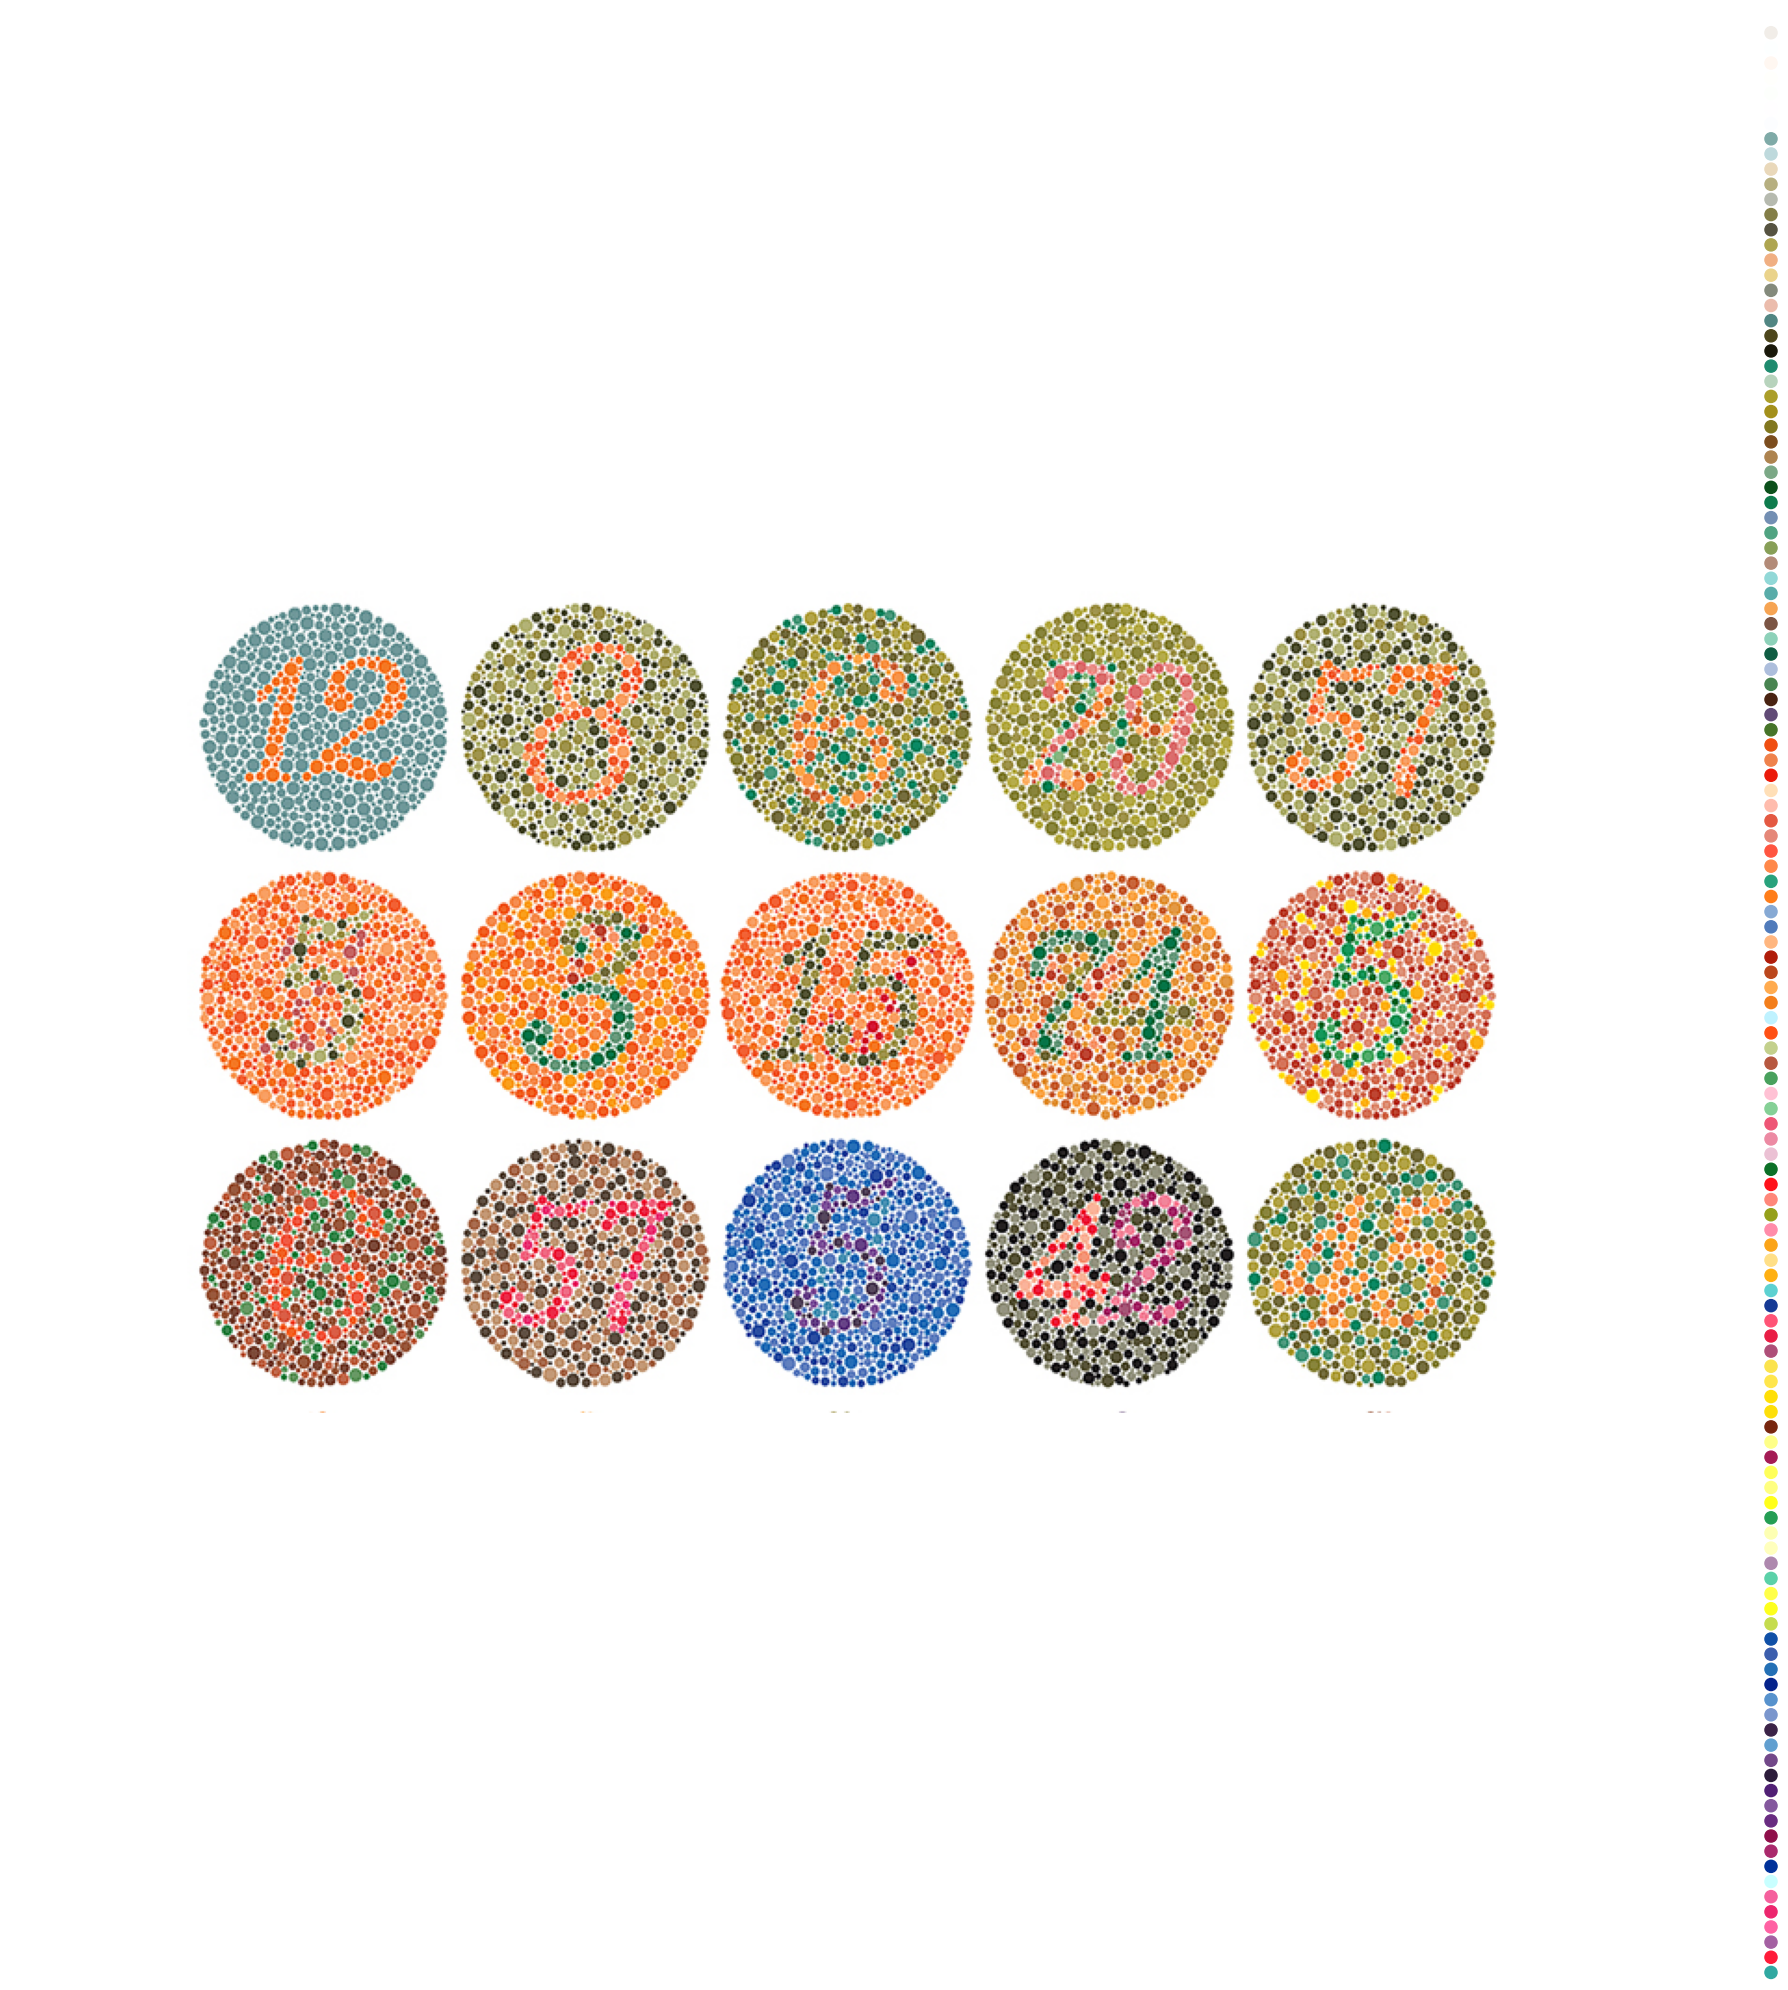

In [27]:
image_path = "images/set_of_tests.jpg"
cube_slength = 5
rep_color_visualization(image_path, cube_slength)

In [28]:
# visualizes an image, with representative colors separated into confusing and non-confusing columns to the right of the image
# takes in image path as string, side length of color bin cubes, and blindness parameter
def separated_rep_color_visualization(image_path, cube_slength, blindness_param, delta):
    rep_color_list, _ = rep_colors(image_path, cube_slength) # pyright: ignore[reportUndefinedVariable]
    dichromat_color_list = [dichromat_simul(c, blindness_param) for c in rep_color_list]
    confusing_color_set, nonconfusing_color_set = sep_confusing(rep_color_list, dichromat_color_list, delta)

    norm_c_colors = [(r/255, g/255, b/255) for r, g, b in confusing_color_set] # normalize to 0–1
    norm_nc_colors = [(r/255, g/255, b/255) for r, g, b in nonconfusing_color_set]
    # print(norm_c_colors)

    img = np.array(Image.open(image_path))

    fig, ax = plt.subplots(1, 2, figsize=(18, 18), gridspec_kw={'width_ratios': [4, 1]})

    # Show image
    ax[0].imshow(img)
    ax[0].axis('off')

    # show color dots
    ax[1].axis('off')
    ax[1].set_aspect('equal', 'box')

    x_conf = 0.4
    x_nonconf = 1.2

    max_rows = max(len(norm_c_colors), len(norm_nc_colors))

    ax[1].text(x_conf, max_rows + 0.3, "Confusing Representative Colors", ha="center", va="bottom", fontsize=10, rotation=90)
    ax[1].text(x_nonconf, max_rows + 0.3, "Nonconfusing Representative Colors", ha="center", va="bottom", fontsize=10, rotation=90)

    for i, color in enumerate(norm_c_colors):
        # print(color)
        circle = patches.Circle((x_conf, len(norm_c_colors)-i-0.5), 0.3, color=color)
        ax[1].add_patch(circle)
    
    for i, color in enumerate(norm_nc_colors):
        # print(color)
        circle = patches.Circle((x_nonconf, len(norm_c_colors)-i-0.5), 0.3, color=color)
        ax[1].add_patch(circle)

    ax[1].set_xlim(0, 2)
    ax[1].set_ylim(0, max_rows)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

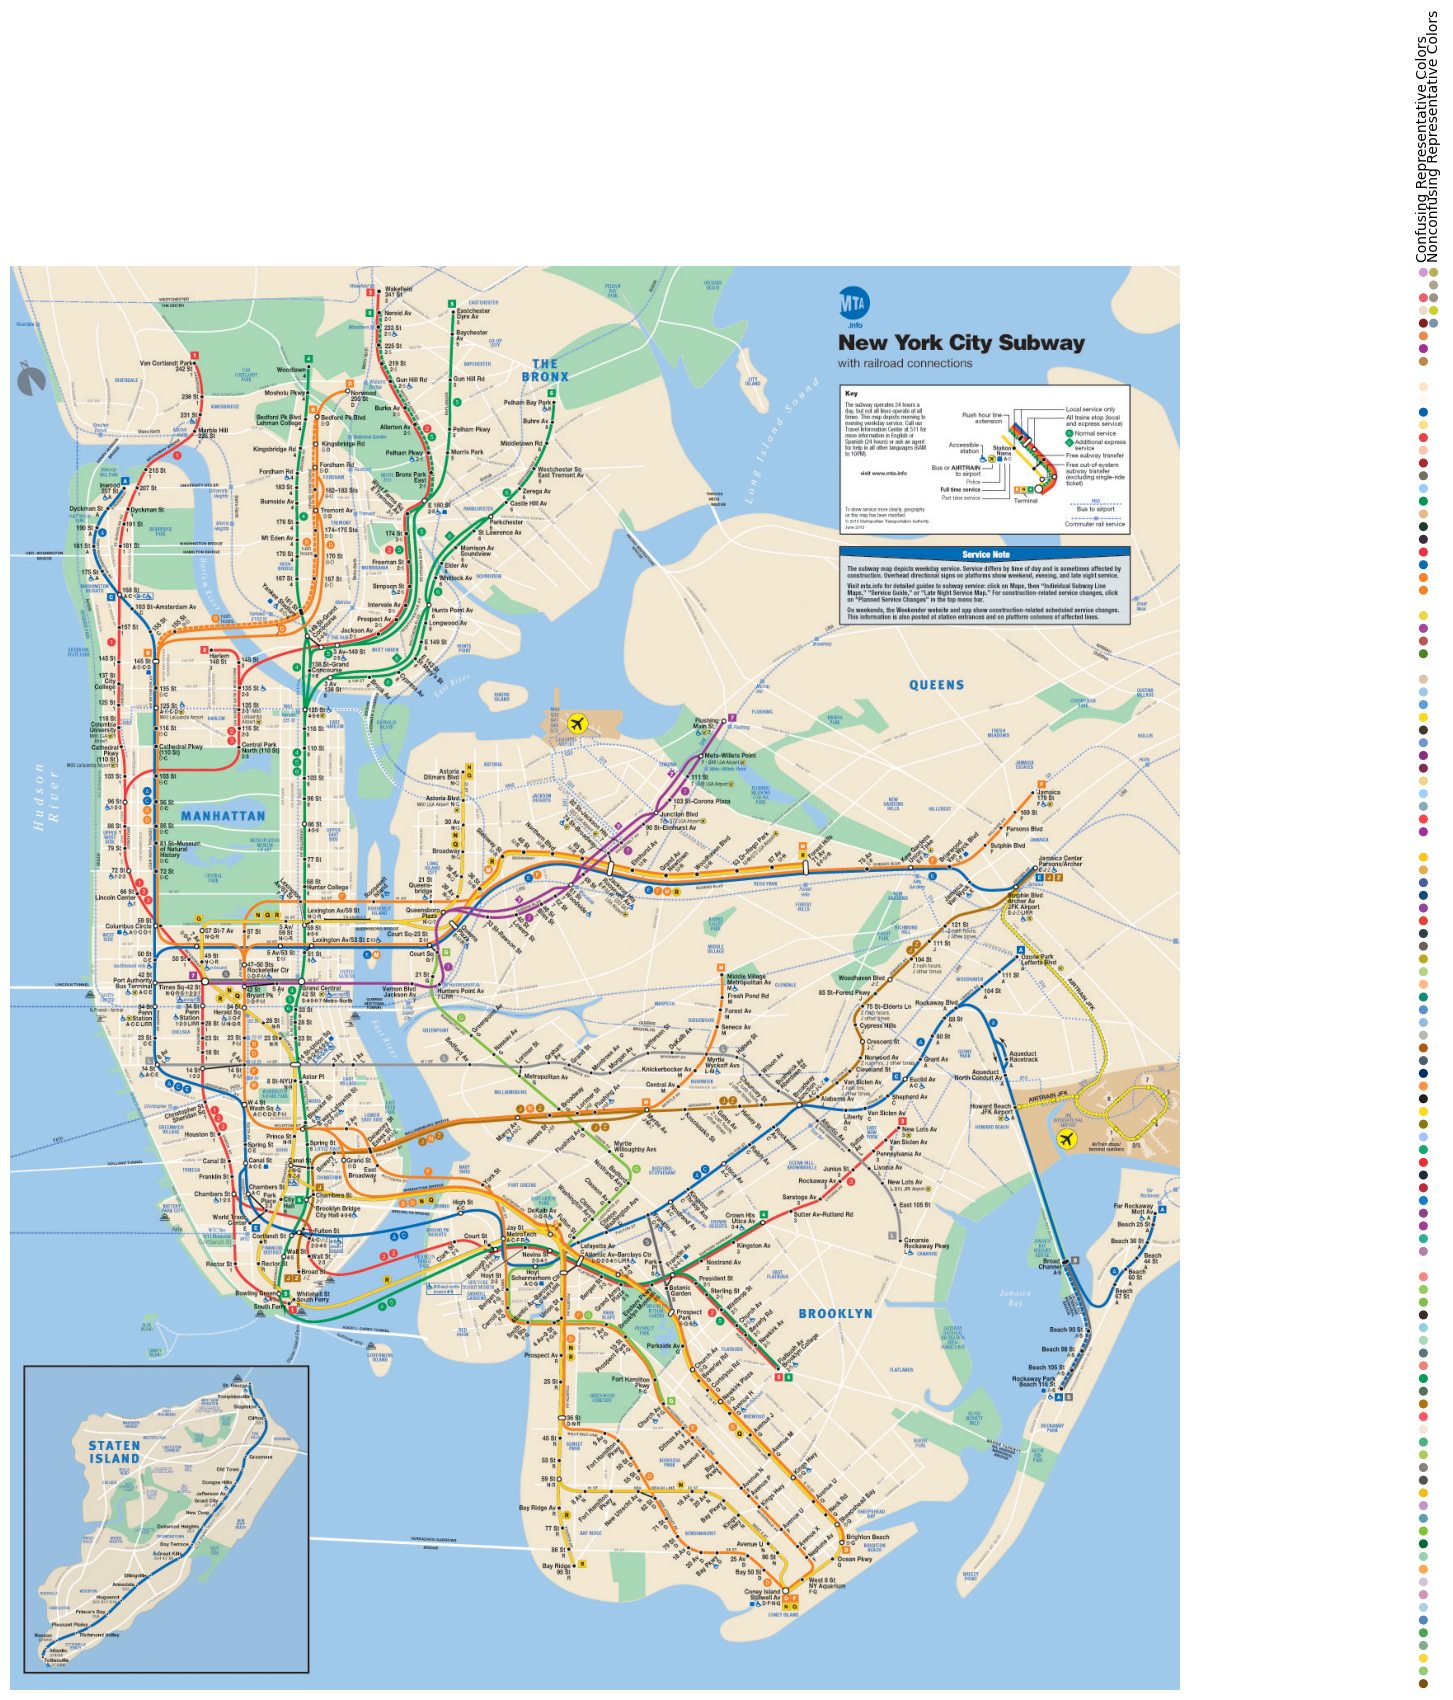

In [29]:
image_path = "images/nyc_map.jpg"
cube_slength = 5
blindness_param = protan
delta = 25
separated_rep_color_visualization(image_path, cube_slength, blindness_param, delta)

In [34]:
# visualizes nonconfusing color clusters
# takes in image path as string, side length of color bin cubes, blindness parameter, delta, and n = number of key nonconfusing colors
def nonconf_cluster_visualization(image_path, cube_slength, blindness_param, delta, n):
    rep_color_list, _ = rep_colors(image_path, cube_slength)
    dichromat_color_list = [dichromat_simul(c, blindness_param) for c in rep_color_list]
    confusing_color_set, nonconfusing_color_set = sep_confusing(rep_color_list, dichromat_color_list, delta)
    _, nonconf_clusters = fuzzy_clustering(nonconfusing_color_set, n)

    # normalize RGB colors to [0, 1]
    def normalize_color(color):
        return (color[0] / 255, color[1] / 255, color[2] / 255)

    # create the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.axis("off")

    large_bubble_radius = 0.2
    small_bubble_radius = 0.025

    y_offset = 1 # vertical offset to space out each group

    for idx, (key_color, clustered_colors) in enumerate(nonconf_clusters.items()):
        k_color = normalize_color(key_color)
        
        # plot the main large bubble
        ax.add_patch(plt.Circle((0.5, y_offset), large_bubble_radius, color=k_color, ec='black'))

        # plot the small bubbles
        for j, clus_color in enumerate(clustered_colors):
            cl_color = normalize_color(clus_color)
            # small bubbles surrounding the main bubble
            angle = np.linspace(0, 2 * np.pi, len(clustered_colors), endpoint=False)[j]
            x_offset = 0.25 * np.cos(angle)
            y_offset_small = 0.25 * np.sin(angle)
            ax.add_patch(plt.Circle((0.5 + x_offset, y_offset + y_offset_small), small_bubble_radius, color=cl_color, ec='black'))

        # move down the plot for the next main color
        y_offset -= 0.6

    padding = 0.2  # padding around bubbles
    max_offset = large_bubble_radius + 0.13 + small_bubble_radius + padding

    ax.set_xlim(0.5 - max_offset, 0.5 + max_offset)  
    ax.set_ylim(y_offset - max_offset, 1 + max_offset) 
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

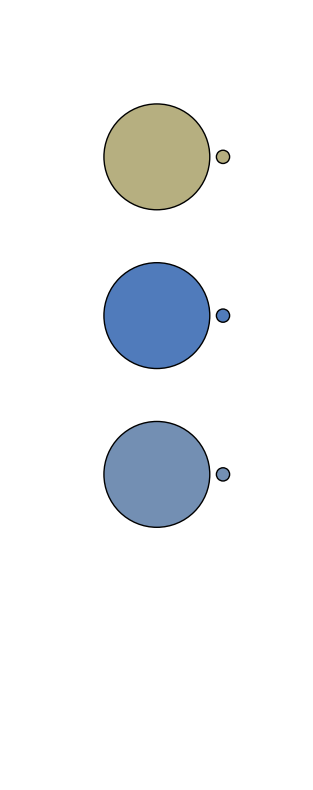

In [35]:
img_path = "images/set_of_tests.jpg"
cube_slength = 5
blindness_param = protan
delta = 25
n = 4
nonconf_cluster_visualization(img_path, cube_slength, blindness_param, delta, n)

In [20]:
# visualizes confusing color clusters
# takes in image path as string, side length of color bin cubes, blindness parameter, delta, and m = number of key confusing colors
def conf_cluster_visualization(image_path, cube_slength, blindness_param, delta, m):
    rep_color_list, _ = rep_colors(img_path, cube_slength)
    dichromat_color_list = [dichromat_simul(c, blindness_param) for c in rep_color_list]
    confusing_color_set, nonconfusing_color_set = sep_confusing(rep_color_list, dichromat_color_list, 25)
    m = 4
    _, conf_clusters = fuzzy_clustering(confusing_color_set, m)

    # normalize RGB colors to [0, 1]
    def normalize_color(color):
        return (color[0] / 255, color[1] / 255, color[2] / 255)

    # create the plot
    fig, ax = plt.subplots(figsize=(8, 8))

    ax.axis("off")

    large_bubble_radius = 0.2
    small_bubble_radius = 0.025

    y_offset = 1 # vertical offset to space out each group

    for idx, (key_color, clustered_colors) in enumerate(conf_clusters.items()):
        k_color = normalize_color(key_color)
        
        # plot the main large bubble
        ax.add_patch(plt.Circle((0.5, y_offset), large_bubble_radius, color=k_color, ec='black'))

        # plot the small bubbles
        for j, clus_color in enumerate(clustered_colors):
            cl_color = normalize_color(clus_color)
            # small bubbles surrounding the main bubble
            angle = np.linspace(0, 2 * np.pi, len(clustered_colors), endpoint=False)[j]
            x_offset = 0.25 * np.cos(angle)
            y_offset_small = 0.25 * np.sin(angle)
            ax.add_patch(plt.Circle((0.5 + x_offset, y_offset + y_offset_small), small_bubble_radius, color=cl_color, ec='black'))

        # move down the plot for the next main color
        y_offset -= 0.6

    padding = 0.2  # padding around bubbles
    max_offset = large_bubble_radius + 0.13 + small_bubble_radius + padding

    ax.set_xlim(0.5 - max_offset, 0.5 + max_offset)  
    ax.set_ylim(y_offset - max_offset, 1 + max_offset) 
    ax.set_aspect('equal')

    plt.tight_layout()
    plt.show()

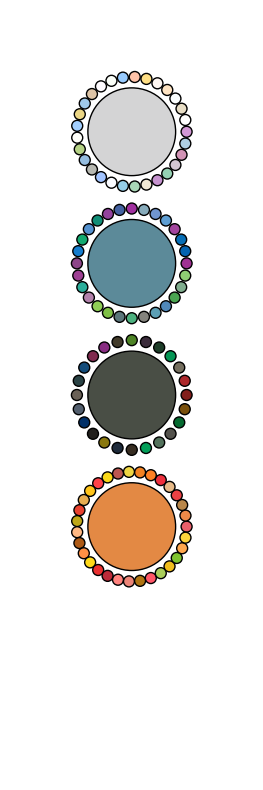

In [21]:
img_path = "images/nyc_map.jpg"
cube_slength = 5
blindness_param = protan
delta = 25
m = 4
conf_cluster_visualization(img_path, cube_slength, blindness_param, delta, m)

COLORS TO TRANSLATE
[(0.4392458519257049, 0.3951075455996305), (0.3375540335489562, 0.3510344457906112), (0.5303341733707926, 0.32683445952666046), (0.42730554804777754, 0.43365743473181634)]


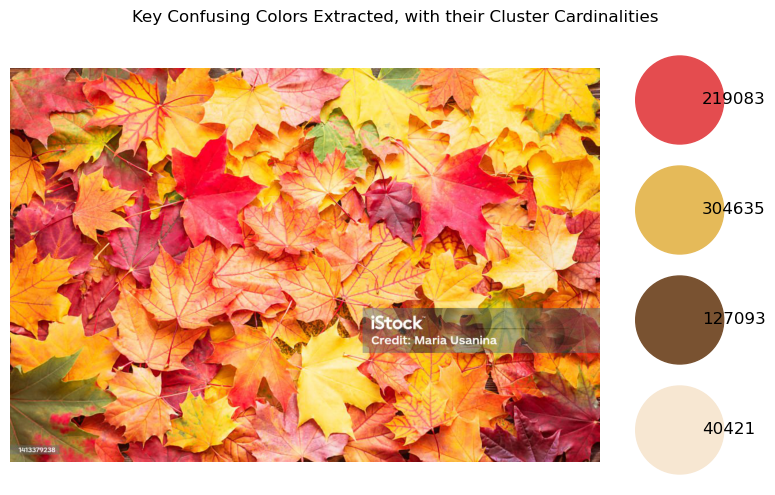

In [170]:
img_path = "images/foliage.jpg"
cube_slength = 5
blindness_param = protan
delta = 25
m = 4
n = 4
num_confusion_lines = 10
copunctal = (0.747, 0.253)

key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities = module_1(img_path, cube_slength, delta, blindness_param, m, n)
conf_heap, nonconf_heap, key_c_xy_dict, key_nc_xy_dict, colors_to_translate, color_translation_map = module_2(key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities, num_confusion_lines, copunctal)
norm_c_colors = [(r/255, g/255, b/255) for r, g, b in conf_cardinalities]  # normalize to 0–1

img = np.array(Image.open(img_path))

fig, ax = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [4, 1]})
fig.suptitle("Key Confusing Colors Extracted, with their Cluster Cardinalities")

# Show image
ax[0].imshow(img)
ax[0].axis('off')

# show color dots
ax[1].axis('off')
ax[1].set_aspect('equal', 'box')

for i, color in enumerate(norm_c_colors):
    circle = patches.Circle((0.5, len(norm_c_colors)-i-0.5), 0.4, color=color)
    ax[1].add_patch(circle)
    ax[1].text(0.7, len(norm_c_colors)-i-0.5, conf_cardinalities[(color[0] * 255, color[1] * 255, color[2] * 255)], va='center', ha='left', fontsize=12)
    
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, len(norm_c_colors))

plt.tight_layout()
plt.show()

COLORS TO TRANSLATE
[(0.26994056701406416, 0.3268642312239813), (0.3415659687815031, 0.36237873588751274), (0.5019093275880674, 0.3861201737404019), (0.3192834962507761, 0.3343415646359983)]
NORM NC COLORS
[(0.3137310265661789, 0.4830339100560214, 0.7345070357469368), (0.7123481943973115, 0.6881206411793939, 0.5004778422864232), (0.45011395862693043, 0.5600779442211654, 0.7037841223445904)]


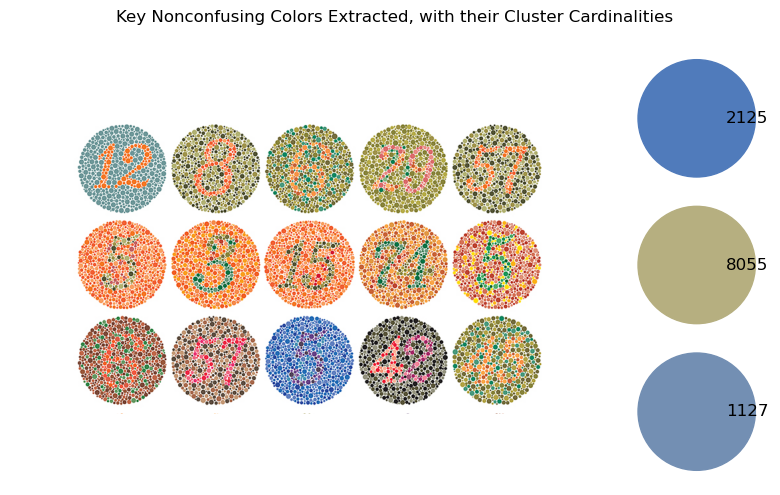

In [194]:
img_path = "images/set_of_tests.jpg"
cube_slength = 5
blindness_param = protan
delta = 25
m = 4
n = 3
num_confusion_lines = 10
copunctal = (0.747, 0.253)

key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities = module_1(img_path, cube_slength, delta, blindness_param, m, n)
conf_heap, nonconf_heap, key_c_xy_dict, key_nc_xy_dict, colors_to_translate, color_translation_map = module_2(key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities, num_confusion_lines, copunctal)
norm_nc_colors = [(r/255, g/255, b/255) for r, g, b in nonconf_cardinalities]  # normalize to 0–1
colors = list(nonconf_cardinalities.keys())

img = np.array(Image.open(img_path))

fig, ax = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'width_ratios': [4, 1]})
fig.suptitle("Key Nonconfusing Colors Extracted, with their Cluster Cardinalities")

# Show image
ax[0].imshow(img)
ax[0].axis('off')

# show color dots
ax[1].axis('off')
ax[1].set_aspect('equal', 'box')

print("NORM NC COLORS")
print(norm_nc_colors)

for i, color in enumerate(norm_nc_colors):
    circle = patches.Circle((0.5, len(norm_nc_colors)-i-0.5), 0.4, color=color)
    ax[1].add_patch(circle)
    ax[1].text(0.7, len(norm_nc_colors)-i-0.5, nonconf_cardinalities[colors[i]], va='center', ha='left', fontsize=12)
    
ax[1].set_xlim(0, 1)
ax[1].set_ylim(0, len(norm_nc_colors))

plt.tight_layout()
plt.show()

## Key Color Translation Visualization

In [199]:
modules_1_and_2("images/foliage.jpg", 5, 25, deutan, 4, 4, 10)

COLORS TO TRANSLATE
[(0.5333841431903529, 0.3285007285486279), (0.4159104842183117, 0.4289894959930852), (0.44210585600041485, 0.3936974305501237)]
[(-266214, (219.9448155346839, 183.72478340180587, 95.8412272408028)), (-230154, (229.45728657879195, 75.64221482017759, 76.9246729484948)), (-40234, (247.29785494233468, 232.01346589484237, 210.30087798457075)), (-127093, (120.07725021972523, 79.857821647089, 48.14779907714361))]
[(-35697, (246.2245566853414, 177.53138919231503, 23.647393338375153))]
{(219.9448155346839, 183.72478340180587, 95.8412272408028): (0.4159104842183117, 0.4289894959930852), (120.07725021972523, 79.857821647089, 48.14779907714361): (0.44210585600041485, 0.3936974305501237), (247.29785494233468, 232.01346589484237, 210.30087798457075): (0.3374502766688375, 0.3512324862889787), (229.45728657879195, 75.64221482017759, 76.9246729484948): (0.5333841431903529, 0.3285007285486279)}
{(246.2245566853414, 177.53138919231503, 23.647393338375153): (0.4771002316501303, 0.45311

In [200]:
modules_1_and_2("images/seven_test.png", 5, 25, deutan, 4, 4, 10)

COLORS TO TRANSLATE
[(0.3550227737016942, 0.4401766717072668), (0.3193029888018792, 0.3342982286146648), (0.37993112379072186, 0.38127501468870334)]
[(-718439, (248.4675803574247, 243.33692384209328, 237.9905730514277)), (-556140, (226.3950950080051, 117.76668754948349, 59.156298656343466)), (-154100, (223.05467753231494, 187.6761250497063, 143.02186373775467)), (-61653, (101.63615174025776, 115.76087505130808, 64.42880232650302))]
[(-2808, (194.6869658119661, 133.80804843304864, 110.5833333333328)), (0, (194.6869658119661, 133.80804843304864, 110.58333333333282))]
{(101.63615174025776, 115.76087505130808, 64.42880232650302): (0.3550227737016942, 0.4401766717072668), (226.3950950080051, 117.76668754948349, 59.156298656343466): (0.5096972951848868, 0.38760440192277845), (223.05467753231494, 187.6761250497063, 143.02186373775467): (0.37993112379072186, 0.38127501468870334), (248.4675803574247, 243.33692384209328, 237.9905730514277): (0.3193029888018792, 0.3342982286146648)}
{(194.6869658

In [201]:
modules_1_and_2("images/set_of_tests.jpg", 5, 25, deutan, 4, 4, 10)

COLORS TO TRANSLATE
[(0.2682995953267037, 0.3260680424532513), (0.3415849583228982, 0.3623837369924714), (0.32089731191430926, 0.3347338311815924)]
[(-279367, (235.89884691975777, 224.8815373829846, 193.66716704643574)), (-56821, (231.0878621287632, 122.63219305040295, 65.55818484002546)), (-38541, (75.93237685212254, 73.50959980650156, 71.53525495333267)), (-17163, (106.35898155208277, 153.81105052993942, 155.4476099767166))]
[(-8055, (181.64878957169392, 175.47076350093062, 127.62184978274362)), (-2125, (80.00141176470592, 123.17364705882297, 187.29929411764715)), (-1801, (179.38700721821198, 139.3076068850651, 119.80621876735225)), (-1127, (114.77905944986726, 142.81987577639717, 179.46495119787053))]
{(235.89884691975777, 224.8815373829846, 193.66716704643574): (0.3415849583228982, 0.3623837369924714), (231.0878621287632, 122.63219305040295, 65.55818484002546): (0.5031966225535996, 0.3863063848532274), (75.93237685212254, 73.50959980650156, 71.53525495333267): (0.32089731191430926,

COLORS TO TRANSLATE
[(0.3192836454557169, 0.3343415894544659), (0.50190928387187, 0.3861202070959903), (0.34156594715858934, 0.3623787156081769), (0.26994053007081337, 0.3268642098782152)]


/Users/rtang/miniconda3/envs/mike/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)  # noqa: B028
/Users/rtang/miniconda3/envs/mike/lib/python3.13/site-packages/colour/utilities/verbose.py:322: ColourUsageWarning: "standalone" argument has been renamed to "show".
  warn(*args, **kwargs)  # noqa: B028


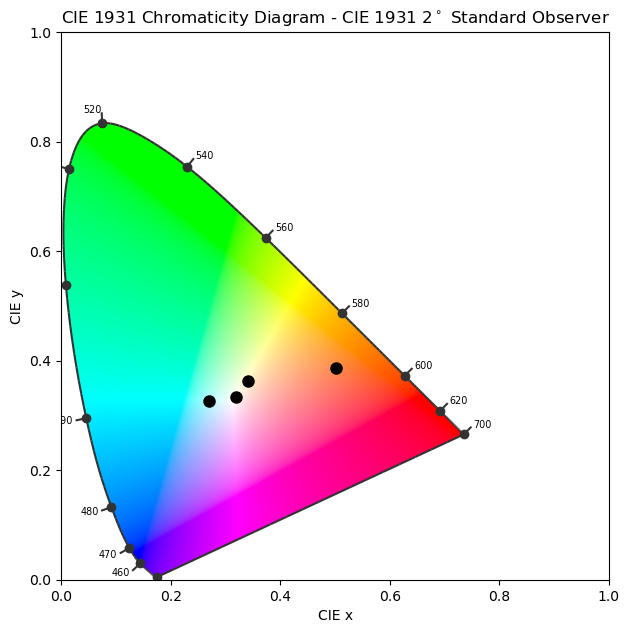

In [192]:
img_path = "images/set_of_tests.jpg"
cube_slength = 5
blindness_param = protan
delta = 25
m = 4
n = 4
num_confusion_lines = 20
copunctal = (0.747, 0.253)

key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities = module_1(img_path, cube_slength, delta, blindness_param, m, n)
conf_heap, nonconf_heap, key_c_xy_dict, key_nc_xy_dict, colors_to_translate, color_translation_map = module_2(key_c_colors, key_nc_colors, conf_cardinalities, nonconf_cardinalities, num_confusion_lines, copunctal)

import colour
import colour.plotting

# fig, ax = plt.subplots(figsize=(8, 8))

fig, ax = colour.plotting.plot_chromaticity_diagram_CIE1931(
    show_diagram_colours=True, 
    show_spectral_locus=True,
    standalone=False
)

# print(key_c_xy_dict)

for (r, g, b), (x, y) in key_c_xy_dict.items():
    plt.plot(x, y, 'o', color='black', markersize=8)

# conf_lines = confusion_lines(20)
# copunctal = (0.747, 0.253)

# for i in range(10):
#     ax.plot((conf_lines[i][0], copunctal[0]), (conf_lines[i][1], copunctal[1]), 'r-', label='My Line') # 'r-' for red solid line

# display the plot
plt.tight_layout()
plt.show()

In [ ]:
# Raven to dos:
# reformat this notebook with a section for visualizing output
# fix cardinality of 0 colors being carried forward issue (basically need to cut off decimal at some point)
# save all visualized images into this repo
# push to github